In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

background_data = pd.read_csv("/Users/sidre/Desktop/Class work/Capstone/Module0/module0-class-survey-team11/data/background-clean.csv")
background_data.head()

,response_id,prog.prof,prog.comf,math.prof,math.comf,stat.prof,stat.comf,upper_div_courses,courses,domain_specialization,research
0,1001,int,4.0,int,4.0,adv,5.0,9+,"PSTAT 115, PSTAT 120, PSTAT 122, PSTAT 126, PS...",Yes,No
1,1002,int,4.0,int,3.0,int,5.0,6-8,"PSTAT 120, PSTAT 126, CS 9, LING 110",Yes,Yes
2,1003,beg,3.0,int,3.0,adv,4.0,6-8,"PSTAT 120, PSTAT 122, PSTAT 126, PSTAT 131, PS...",Yes,No
3,1004,adv,4.0,adv,5.0,adv,5.0,9+,"PSTAT 100, PSTAT 120, PSTAT 122, PSTAT 126, PS...",No,No
4,1005,adv,4.0,int,4.0,adv,5.0,6-8,"PSTAT 120, PSTAT 131, PSTAT 160, CS 5, CS 9",No,No


## Most popular courses

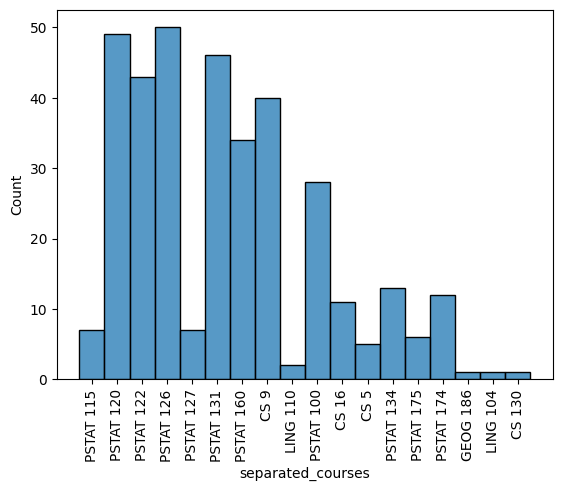

In [2]:
background_data["separated_courses"] = background_data['courses'].str.split(", ")
exploded_data = background_data.explode('separated_courses')
sns.histplot(exploded_data, x='separated_courses');
plt.xticks(rotation=90);

In [3]:
summary_data = pd.read_csv("/Users/sidre/Desktop/Class work/Capstone/Module0/module0-class-survey-team11/data/class-summary.csv")
summary_data.head()

,group,category,n,percent
0,standing,Senior,49,89.1
1,standing,Junior,5,9.1
2,standing,Junior (senior credits),1,1.8
3,gender,Male,30,54.5
4,gender,Female,23,41.8


In [4]:
interest_data = pd.read_csv("/Users/sidre/Desktop/Class work/Capstone/Module0/module0-class-survey-team11/data/interest-clean.csv")
interest_data.head()

,response_id,type,language,domains,areas
0,1001,both,R,"Environmental science, Social or political sci...","Spatial statistics or time series analysis, Da..."
1,1002,ind,Python,"Environmental science, Social or political sci...","Analysis or classification of images, Spatial ..."
2,1003,lab,No preference,"Environmental science, Social or political sci...","Analysis or classification of images, Deep lea..."
3,1004,ind,Python,"Biology, Neuroscience, Technology, Software de...","Deep learning and neural networks, Natural lan..."
4,1005,both,No preference,"Social or political science, Public health, Ne...","Analysis or classification of images, Deep lea..."


## Most popular subject areas

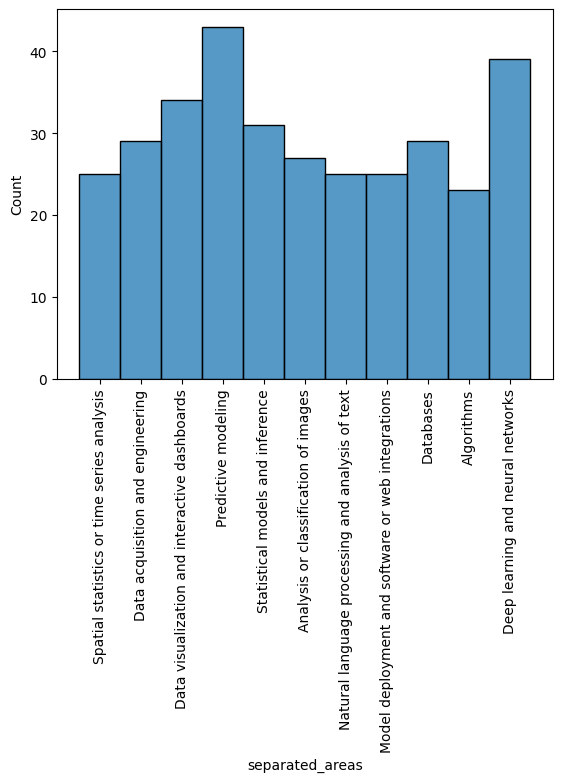

In [5]:
interest_data['separated_areas'] = interest_data['areas'].str.split(', ')
exploded_data_intrest = interest_data.explode('separated_areas')
cleaned_interest_df = exploded_data_intrest[exploded_data_intrest['separated_areas'] != 'generally']
sns.histplot(cleaned_interest_df, x='separated_areas');
plt.xticks(rotation=90);

## Heatmap


<Axes: >

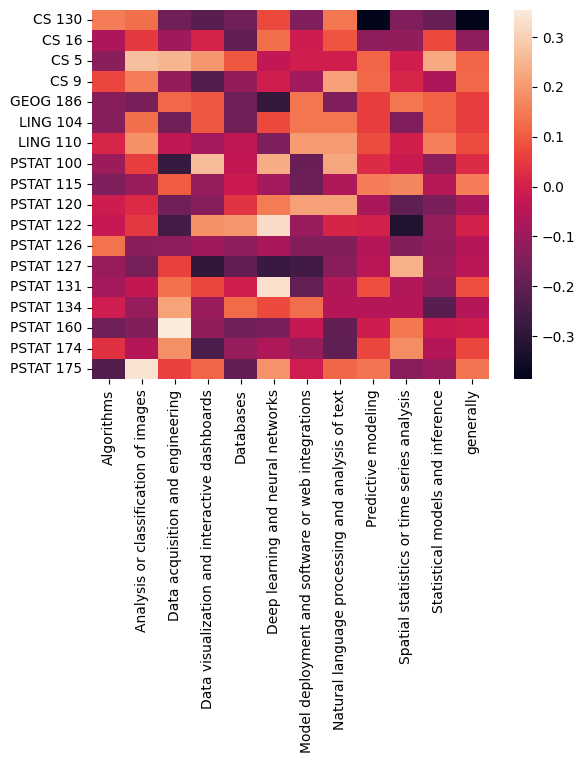

In [19]:
from posixpath import sep
merged_df = pd.merge(background_data, interest_data, on='response_id')
merged_df = merged_df.drop(columns=['separated_courses', 'separated_areas'])
dummy_courses = merged_df['courses'].str.get_dummies(sep=', ')
dummy_areas = merged_df['areas'].str.get_dummies(sep=', ')
dummy_table = pd.concat([dummy_courses, dummy_areas], axis=1)
correlation = dummy_table.corr()

courses_area_corr = correlation.loc[dummy_courses.columns, dummy_areas.columns]

sns.heatmap(courses_area_corr)
